In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
import joblib





In [2]:
df=pd.read_csv(r"C:\Users\GOD\Downloads\Data_Leakage_Detection.csv.zip")

In [3]:
df.shape

(49500, 15)

In [4]:
df.size

742500

In [5]:
df.dtypes

id                              int64
date                           object
user                           object
pc                             object
Authority                      object
Through_pwd                   float64
Through_pin                   float64
Through_MFA                   float64
Data Modification             float64
Confidential Data Access      float64
Confidential File Transfer    float64
External Destination           object
File Operation                 object
Data Sensitivity Level         object
Abnormality                     int64
dtype: object

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.columns=df.columns.str.replace(' ','_')

In [8]:
df=df.drop(columns=['id','date','user','pc'])

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49500 entries, 0 to 49499
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Authority                   49007 non-null  object 
 1   Through_pwd                 49002 non-null  float64
 2   Through_pin                 49006 non-null  float64
 3   Through_MFA                 49147 non-null  float64
 4   Data_Modification           49006 non-null  float64
 5   Confidential_Data_Access    49000 non-null  float64
 6   Confidential_File_Transfer  49005 non-null  float64
 7   External_Destination        49006 non-null  object 
 8   File_Operation              49006 non-null  object 
 9   Data_Sensitivity_Level      49018 non-null  object 
 10  Abnormality                 49500 non-null  int64  
dtypes: float64(6), int64(1), object(4)
memory usage: 4.2+ MB


In [10]:
df.head() 

,Authority,Through_pwd,Through_pin,Through_MFA,Data_Modification,Confidential_Data_Access,Confidential_File_Transfer,External_Destination,File_Operation,Data_Sensitivity_Level,Abnormality
0,manager,0.0,0.0,1.0,0.0,0.0,1.0,internal,move,low,0
1,staff,1.0,0.0,0.0,1.0,0.0,0.0,external,write,low,1
2,manager,0.0,0.0,1.0,1.0,0.0,1.0,internal,write,low,0
3,staff,0.0,1.0,0.0,0.0,1.0,1.0,internal,move,high,0
4,senior manager,0.0,0.0,1.0,0.0,1.0,0.0,external,read,high,0


In [11]:
df.tail()

,Authority,Through_pwd,Through_pin,Through_MFA,Data_Modification,Confidential_Data_Access,Confidential_File_Transfer,External_Destination,File_Operation,Data_Sensitivity_Level,Abnormality
49495,manager,0.0,1.0,0.0,1.0,0.0,0.0,external,read,high,1
49496,intern,1.0,1.0,1.0,0.0,1.0,1.0,internal,move,medium,1
49497,manager,1.0,0.0,0.0,1.0,0.0,0.0,external,write,medium,0
49498,intern,0.0,0.0,1.0,1.0,1.0,1.0,internal,delete,medium,1
49499,manager,0.0,1.0,0.0,0.0,0.0,1.0,internal,read,low,0


In [12]:
df.dtypes

Authority                      object
Through_pwd                   float64
Through_pin                   float64
Through_MFA                   float64
Data_Modification             float64
Confidential_Data_Access      float64
Confidential_File_Transfer    float64
External_Destination           object
File_Operation                 object
Data_Sensitivity_Level         object
Abnormality                     int64
dtype: object

In [13]:
df.describe()

,Through_pwd,Through_pin,Through_MFA,Data_Modification,Confidential_Data_Access,Confidential_File_Transfer,Abnormality
count,49002.000000,49006.000000,49147.000000,49006.000000,49000.000000,49005.000000,49500.000000
mean,0.272336,0.283700,0.488209,0.388626,0.336163,0.545271,0.311010
std,0.445166,0.450798,0.499866,0.487443,0.472400,0.497951,0.462912
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [14]:
df.isnull().sum()

Authority                     493
Through_pwd                   498
Through_pin                   494
Through_MFA                   353
Data_Modification             494
Confidential_Data_Access      500
Confidential_File_Transfer    495
External_Destination          494
File_Operation                494
Data_Sensitivity_Level        482
Abnormality                     0
dtype: int64

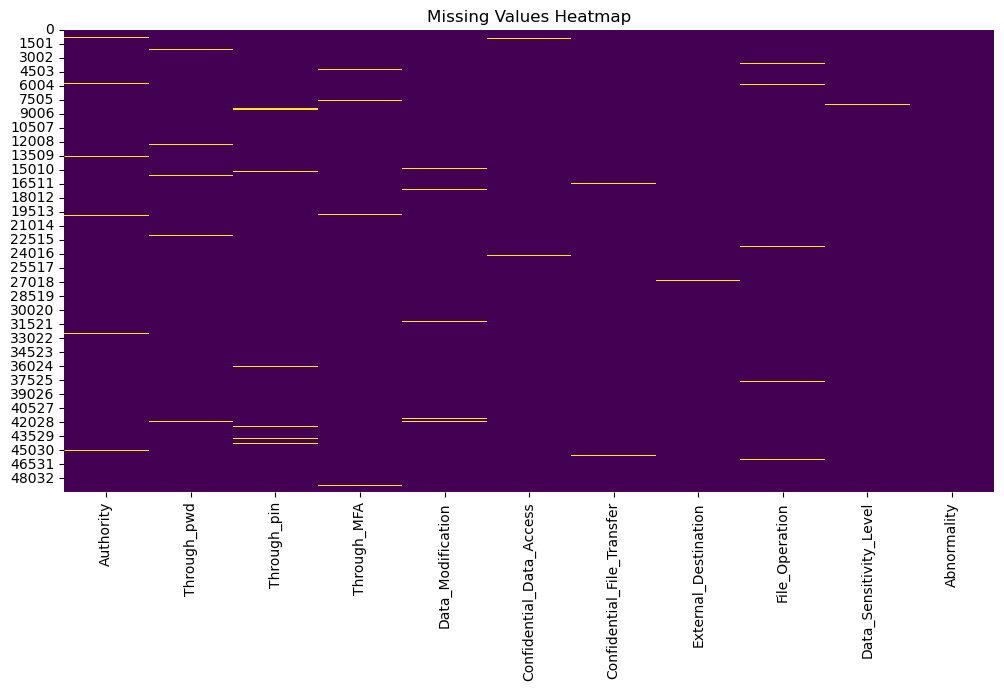

In [15]:
plt.figure(figsize=(12,6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Values Heatmap')
plt.show()

In [16]:
df=df.fillna(0)

In [17]:
df.isnull().sum()

Authority                     0
Through_pwd                   0
Through_pin                   0
Through_MFA                   0
Data_Modification             0
Confidential_Data_Access      0
Confidential_File_Transfer    0
External_Destination          0
File_Operation                0
Data_Sensitivity_Level        0
Abnormality                   0
dtype: int64

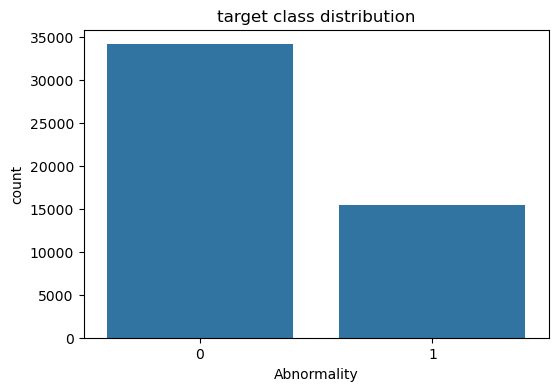

In [18]:
plt.figure(figsize=(6,4))
sns.countplot(x="Abnormality",data=df)
plt.title("target class distribution")
plt.xlabel("Abnormality")
plt.ylabel("count")
plt.show()

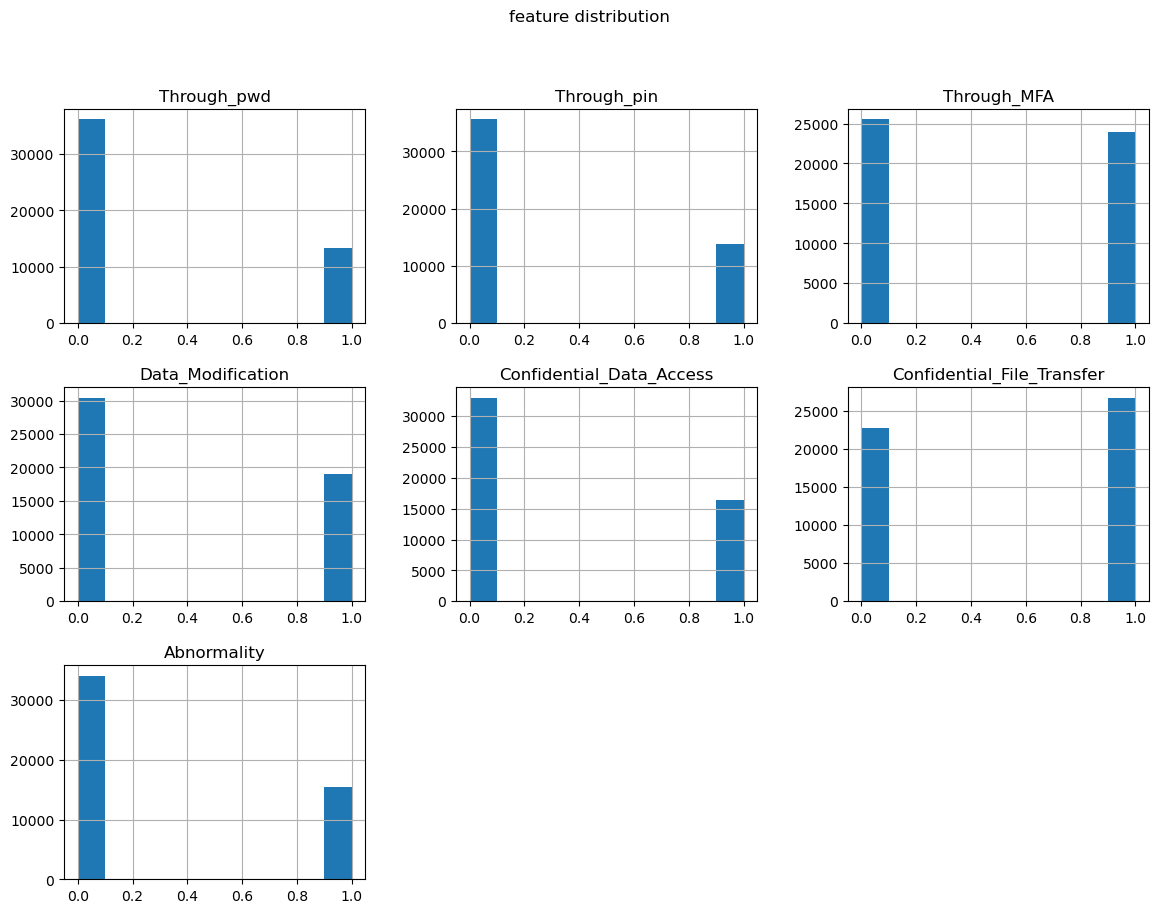

In [19]:
df.hist(figsize=(14,10))
plt.suptitle("feature distribution")
plt.show()

In [20]:
df_numeric=df.select_dtypes(include=['int64','float64'])

In [21]:
df_numeric.corr()

,Through_pwd,Through_pin,Through_MFA,Data_Modification,Confidential_Data_Access,Confidential_File_Transfer,Abnormality
Through_pwd,1.000000,-0.067788,-0.435218,0.014087,0.068425,0.132365,0.115123
Through_pin,-0.067788,1.000000,-0.478156,0.016432,0.040022,0.081612,0.094972
Through_MFA,-0.435218,-0.478156,1.000000,-0.014592,-0.004583,-0.039448,-0.068320
Data_Modification,0.014087,0.016432,-0.014592,1.000000,0.000832,0.002929,0.022318
Confidential_Data_Access,0.068425,0.040022,-0.004583,0.000832,1.000000,0.170759,0.213487
Confidential_File_Transfer,0.132365,0.081612,-0.039448,0.002929,0.170759,1.000000,0.221311
Abnormality,0.115123,0.094972,-0.068320,0.022318,0.213487,0.221311,1.000000


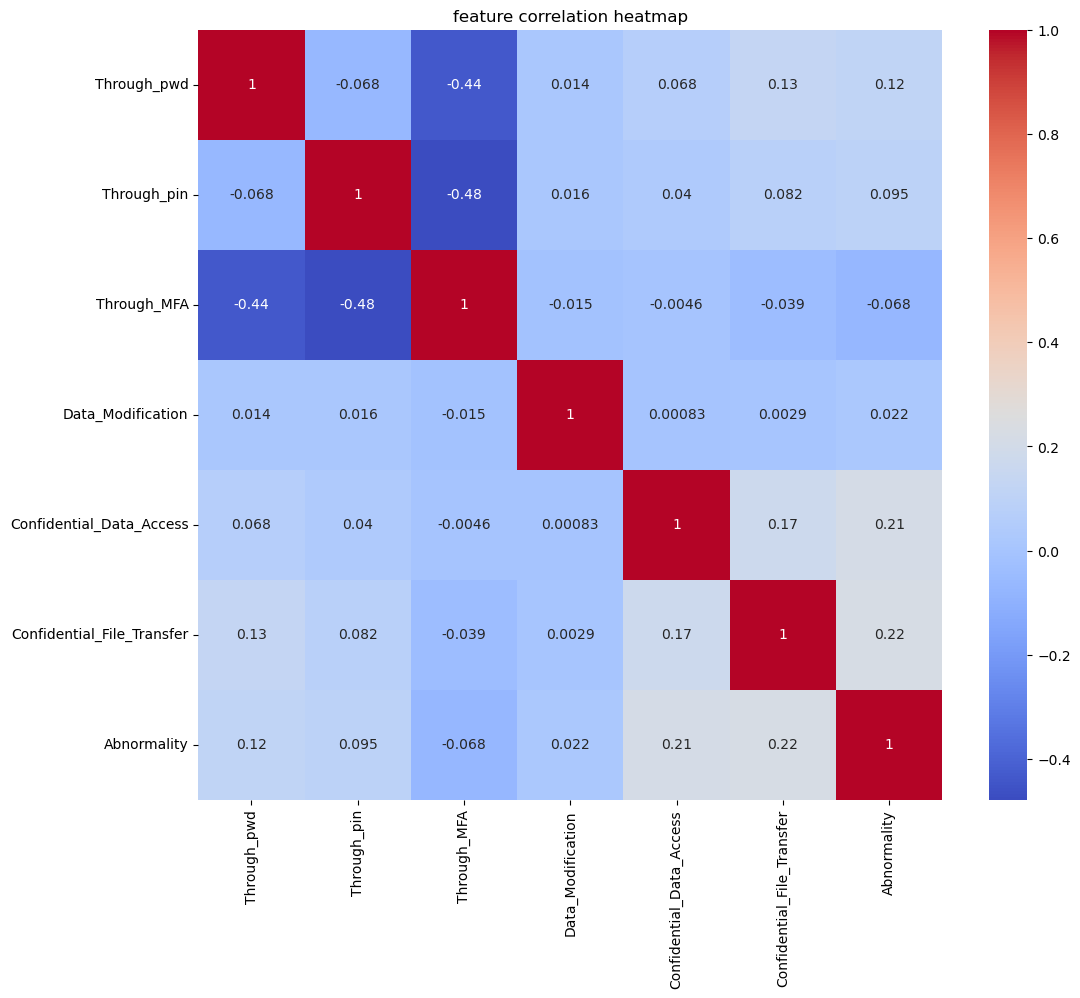

In [22]:
plt.figure(figsize=(12,10))
sns.heatmap(df_numeric.corr(), annot=True,cmap="coolwarm")
plt.title("feature correlation heatmap")
plt.show()

In [23]:
df.dtypes

Authority                      object
Through_pwd                   float64
Through_pin                   float64
Through_MFA                   float64
Data_Modification             float64
Confidential_Data_Access      float64
Confidential_File_Transfer    float64
External_Destination           object
File_Operation                 object
Data_Sensitivity_Level         object
Abnormality                     int64
dtype: object

In [24]:
le=LabelEncoder()
df["Authority"]=le.fit_transform(df["Authority"].astype(str))
for col in df.select_dtypes(include="object").columns:
    df[col]=le.fit_transform(df[col].astype(str))

In [35]:
df.columns = df.columns.str.replace(' ', '_')


In [36]:
features = [
    'Authority',
    'Through_pwd',
    'Through_pin',
    'Through_MFA',
    'Data_Modification',
    'Confidential_Data_Access',
    'Confidential_File_Transfer',
    'External_Destination',
    'File_Operation',
    'Data_Sensitivity_Level'
]

x = df[features]
y = df['Abnormality']

In [37]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.2,random_state=42)

In [38]:
    scaler = StandardScaler()
    xtrain_scaled = scaler.fit_transform(xtrain)
    xtest_scaled=scaler.transform(xtest)

In [39]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=100),
    "SVM": SVC()
}
accuracy_results = {}

for name, model in models.items():
    model.fit(xtrain, ytrain)
    ypred = model.predict(xtest)
    acc = accuracy_score(ytest, ypred)
    accuracy_results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")



Logistic Regression Accuracy: 0.7015
Decision Tree Accuracy: 0.7193
Random Forest Accuracy: 0.7202
SVM Accuracy: 0.7263


In [40]:
best_model = max(accuracy_results, key=accuracy_results.get)

print("Best Algorithm:", best_model)
print("Best Accuracy:", accuracy_results[best_model])

Best Algorithm: SVM
Best Accuracy: 0.7262626262626263


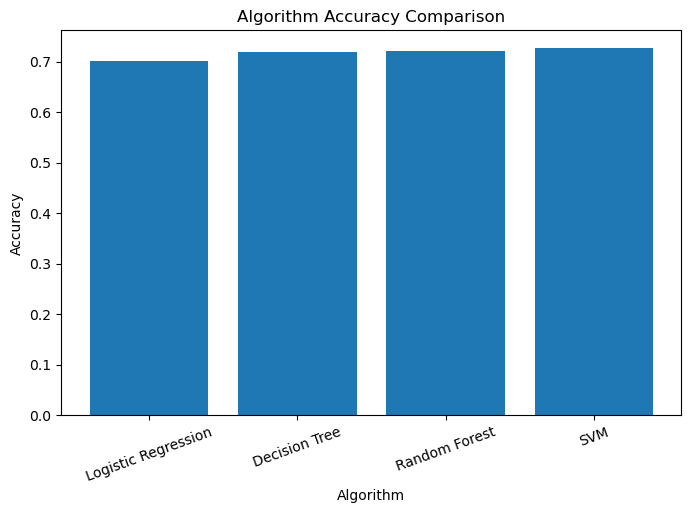

In [41]:
plt.figure(figsize=(8,5))
plt.bar(accuracy_results.keys(), accuracy_results.values())
plt.ylabel("Accuracy")
plt.xlabel("Algorithm")
plt.title("Algorithm Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()

In [42]:
best_model = RandomForestClassifier(n_estimators=100)
best_model.fit(xtrain, ytrain)

RandomForestClassifier()

In [43]:
y_pred = best_model.predict(xtest)
y_pred

array([0, 0, 1, ..., 0, 0, 0])

In [44]:
cm = confusion_matrix(ytest, y_pred)
cm

array([[5576, 1206],
       [1558, 1560]])

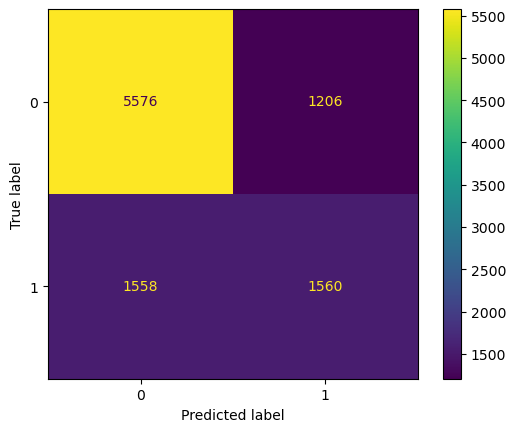

In [45]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

In [46]:
print(classification_report(ytest, y_pred))

              precision    recall  f1-score   support

           0       0.78      0.82      0.80      6782
           1       0.56      0.50      0.53      3118

    accuracy                           0.72      9900
   macro avg       0.67      0.66      0.67      9900
weighted avg       0.71      0.72      0.72      9900



In [47]:
joblib.dump(best_model, "data_leakage_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']